# Peliculas Rotten-Tomatoes
 
En nuestro proyecto vamos a utilizar el rotten_tomatoes_movies.csv
 
Objetivos:
1. Cargar datos.
2. Limpieza y preparación de datos.
3. Análisis exploratorio.
 
    3.1 Estadísticas globales
 
    3.2 Análisis por género
 
    3.3 Análisis por estudio o director
 
    3.4 Análisis temporal
   
    3.5 Análisis de retraso a streaming (si aplica)
4. Uso de NumPy para análisis auxiliar.
5. Preguntas.
6. Conclusiones.

## 1. Carga de datos

In [23]:
# Instala pandas en el kernel actual (usa %pip para asegurar instalación en este entorno)
%pip install -q pandas
%pip install -q matplotlib
%matplotlib inline
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np


# Cargar el CSV 
df = pd.read_csv("rotten_tomatoes_movies.csv")

# Mostramos las primeras filas de nuestro csv
display(df.head())

# Como nuestro csv mayoritariamente tiene texto utilizaremos el .info en vez del .describe que es para numéricas
df.info()

# Estadísticas básicas (incluyendo texto)
display(df.describe(include='all'))

#CONVERSION DE TIPOS
print("Tipos ANTES:")
print(df.dtypes)

# Conversión in_theaters_date y on_streaming_date a datetime
df['in_theaters_date'] = pd.to_datetime(df['in_theaters_date'], errors='coerce', dayfirst=True)
df['on_streaming_date'] = pd.to_datetime(df['on_streaming_date'], errors='coerce', dayfirst=True)

# Conversión in_theaters_date y on_streaming_date a numerico
df['runtime_in_minutes'] = pd.to_numeric(df['runtime_in_minutes'], errors='coerce')
df['tomatometer_rating'] = pd.to_numeric(df['tomatometer_rating'], errors='coerce')
df['audience_rating'] = pd.to_numeric(df['audience_rating'], errors='coerce')
df['tomatometer_count'] = pd.to_numeric(df['tomatometer_count'], errors='coerce')
df['audience_count'] = pd.to_numeric(df['audience_count'], errors='coerce')



print("\nTipos DESPUÉS:")
print(df.dtypes)

display(df.head())


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


,movie_title,movie_info,critics_consensus,rating,genre,directors,writers,cast,in_theaters_date,on_streaming_date,runtime_in_minutes,studio_name,tomatometer_status,tomatometer_rating,tomatometer_count,audience_rating,audience_count,columna_vacia
0,Percy Jackson & the Olympians: The Lightning T...,A teenager discovers he's the descendant of a ...,Though it may seem like just another Harry Pot...,PG,"Action & Adventure, Comedy, Drama, Science Fic...",Chris Columbus,Craig Titley,"Logan Lerman, Brandon T. Jackson, Alexandra Da...",2010-02-12,2010-06-29,83.0,20th Century Fox,Rotten,49,144,53.0,254287.0,NaN
1,Percy Jackson & the Olympians: The Lightning T...,A teenager discovers he's the descendant of a ...,Though it may seem like just another Harry Pot...,PG,"Action & Adventure, Comedy, Drama, Science Fic...",Chris Columbus,Craig Titley,"Logan Lerman, Brandon T. Jackson, Alexandra Da...",2010-02-12,2010-06-29,83.0,20th Century Fox,Rotten,49,144,53.0,254287.0,NaN
2,Please Give,Kate has a lot on her mind. There's the ethics...,Nicole Holofcener's newest might seem slight i...,R,Comedy,Nicole Holofcener,Nicole Holofcener,"Catherine Keener, Amanda Peet, Oliver Platt, R...",2010-04-30,2010-10-19,90.0,Sony Pictures Classics,Certified Fresh,86,140,64.0,11567.0,NaN
3,10,Blake Edwards' 10 stars Dudley Moore as George...,NaN,R,"Comedy, Romance",Blake Edwards,Blake Edwards,"Dudley Moore, Bo Derek, Julie Andrews, Robert ...",1979-10-05,1997-08-27,118.0,Waner Bros.,Fresh,68,22,53.0,14670.0,NaN
4,12 Angry Men (Twelve Angry Men),"A Puerto Rican youth is on trial for murder, a...",Sidney Lumet's feature debut is a superbly wri...,NR,"Classics, Drama",Sidney Lumet,Reginald Rose,"Martin Balsam, John Fiedler, Lee J. Cobb, E.G....",1957-04-13,2001-03-06,95.0,Criterion Collection,Certified Fresh,100,51,97.0,105000.0,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16639 entries, 0 to 16638
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   movie_title         16639 non-null  object 
 1   movie_info          16615 non-null  object 
 2   critics_consensus   8310 non-null   object 
 3   rating              16639 non-null  object 
 4   genre               16622 non-null  object 
 5   directors           16525 non-null  object 
 6   writers             15290 non-null  object 
 7   cast                16355 non-null  object 
 8   in_theaters_date    15824 non-null  object 
 9   on_streaming_date   16637 non-null  object 
 10  runtime_in_minutes  16484 non-null  float64
 11  studio_name         16223 non-null  object 
 12  tomatometer_status  16639 non-null  object 
 13  tomatometer_rating  16639 non-null  int64  
 14  tomatometer_count   16639 non-null  int64  
 15  audience_rating     16387 non-null  float64
 16  audi

,movie_title,movie_info,critics_consensus,rating,genre,directors,writers,cast,in_theaters_date,on_streaming_date,runtime_in_minutes,studio_name,tomatometer_status,tomatometer_rating,tomatometer_count,audience_rating,audience_count,columna_vacia
count,16639,16615,8310,16639,16622,16525,15290,16355,15824,16637,16484.000000,16223,16639,16639.000000,16639.000000,16387.000000,1.638700e+04,0.0
unique,16106,16613,8307,8,1080,8314,12121,16326,5586,2260,NaN,2886,3,NaN,NaN,NaN,NaN,NaN
top,Home,A teenager discovers he's the descendant of a ...,High Life is as visually arresting as it is ch...,R,Drama,Alfred Hitchcock,Woody Allen,Werner Herzog,2002-01-01,2004-06-01,NaN,Paramount Pictures,Rotten,NaN,NaN,NaN,NaN,NaN
freq,5,2,2,6136,1727,36,33,4,28,71,NaN,497,7234,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,102.390318,NaN,NaN,60.465833,56.612357,60.470373,1.524859e+05,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.027707,NaN,NaN,28.586509,66.385262,20.461826,1.817681e+06,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,0.000000,5.000000,0.000000,5.000000e+00,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90.000000,NaN,NaN,38.000000,12.000000,45.000000,8.645000e+02,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99.000000,NaN,NaN,66.000000,28.000000,62.000000,4.877000e+03,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,111.000000,NaN,NaN,86.000000,76.000000,77.000000,2.876650e+04,NaN


Tipos ANTES:
movie_title            object
movie_info             object
critics_consensus      object
rating                 object
genre                  object
directors              object
writers                object
cast                   object
in_theaters_date       object
on_streaming_date      object
runtime_in_minutes    float64
studio_name            object
tomatometer_status     object
tomatometer_rating      int64
tomatometer_count       int64
audience_rating       float64
audience_count        float64
columna_vacia         float64
dtype: object

Tipos DESPUÉS:
movie_title                   object
movie_info                    object
critics_consensus             object
rating                        object
genre                         object
directors                     object
writers                       object
cast                          object
in_theaters_date      datetime64[ns]
on_streaming_date     datetime64[ns]
runtime_in_minutes           float64
studio_nam

C:\Users\Mark\AppData\Local\Temp\ipykernel_35732\1754689757.py:29: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['on_streaming_date'] = pd.to_datetime(df['on_streaming_date'], errors='coerce', dayfirst=True)


,movie_title,movie_info,critics_consensus,rating,genre,directors,writers,cast,in_theaters_date,on_streaming_date,runtime_in_minutes,studio_name,tomatometer_status,tomatometer_rating,tomatometer_count,audience_rating,audience_count,columna_vacia
0,Percy Jackson & the Olympians: The Lightning T...,A teenager discovers he's the descendant of a ...,Though it may seem like just another Harry Pot...,PG,"Action & Adventure, Comedy, Drama, Science Fic...",Chris Columbus,Craig Titley,"Logan Lerman, Brandon T. Jackson, Alexandra Da...",2010-12-02,2010-06-29,83.0,20th Century Fox,Rotten,49,144,53.0,254287.0,NaN
1,Percy Jackson & the Olympians: The Lightning T...,A teenager discovers he's the descendant of a ...,Though it may seem like just another Harry Pot...,PG,"Action & Adventure, Comedy, Drama, Science Fic...",Chris Columbus,Craig Titley,"Logan Lerman, Brandon T. Jackson, Alexandra Da...",2010-12-02,2010-06-29,83.0,20th Century Fox,Rotten,49,144,53.0,254287.0,NaN
2,Please Give,Kate has a lot on her mind. There's the ethics...,Nicole Holofcener's newest might seem slight i...,R,Comedy,Nicole Holofcener,Nicole Holofcener,"Catherine Keener, Amanda Peet, Oliver Platt, R...",NaT,2010-10-19,90.0,Sony Pictures Classics,Certified Fresh,86,140,64.0,11567.0,NaN
3,10,Blake Edwards' 10 stars Dudley Moore as George...,NaN,R,"Comedy, Romance",Blake Edwards,Blake Edwards,"Dudley Moore, Bo Derek, Julie Andrews, Robert ...",1979-05-10,1997-08-27,118.0,Waner Bros.,Fresh,68,22,53.0,14670.0,NaN
4,12 Angry Men (Twelve Angry Men),"A Puerto Rican youth is on trial for murder, a...",Sidney Lumet's feature debut is a superbly wri...,NR,"Classics, Drama",Sidney Lumet,Reginald Rose,"Martin Balsam, John Fiedler, Lee J. Cobb, E.G....",NaT,2001-03-06,95.0,Criterion Collection,Certified Fresh,100,51,97.0,105000.0,NaN


## 2. Limpieza y preparación de datos

In [24]:
# Detectar filas duplicadas completas
duplicados = df[df.duplicated()]
print("Filas duplicadas detectadas:")
display(duplicados)

# Eliminar duplicados
df.drop_duplicates(inplace=True)

print("Tamaño tras eliminar duplicados:", df.shape)

# Conteo de valores nulos por columna
print("Valores nulos por columna:")
print(df.isna().sum())

# Eliminamos columnas que estén completamente vacías
print("Columnas actuales del DataFrame:")
print(df.columns.tolist())
df.dropna(axis=1, how='all', inplace=True)

print("Columnas actuales del DataFrame:")
print(df.columns.tolist())

# Normalizar el campo genre:
# - quitar espacios en blanco
# - poner la primera letra en mayúscula de cada palabra
# - eliminar espacios internos (Acción  -> Acción, 'Ciencia Ficcion' -> 'CienciaFiccion')
df['genre'] = (
    df['genre']
      .astype(str)
      .str.strip()
      .str.title()
      .str.replace(' ', '', regex=False)
)
 
display(df[['genre']].head(10))
 
# Buscar todas las filas que contienen "Horror"
horror_rows = df[df['genre'].str.contains('Horror', case=False, na=False)]
print("Filas con Horror:")
display(horror_rows)

# Aquí vamos a hacer distintas columnas derivadas que nos serviran para hacer distintas busquedas

    # Empezaremos mostrando la diferencia de días entre el estreno en cines y el estreno en teatros.
df['days_to_streaming'] = df['on_streaming_date'] - df['in_theaters_date'] 
print("[Días de diferencia en el estreno")
display(df[['movie_title', 'days_to_streaming']])

#Ahora vamos a contar el total de votos, sumando los votos del tomatometer y los de la audiencia 
df['total_votes'] = df['tomatometer_count'] + df['audience_count']

print("Cantidad de votos")
display(df[['movie_title', 'total_votes']])

#Vamos a hacer una lista de las diferentes películas certificadas
certificado = df['tomatometer_status'] == "Certified Fresh"
print("Peliulas certificadas")
display(df[certificado][['movie_title','studio_name', 'audience_rating']])

Filas duplicadas detectadas:


movie_title  \
11                           Dark Water   
23                             Dead End   
31                          Ultraviolet   
34                          Malevolence   
35                              Eternal   
...                                 ...   
16624                        Zombeavers   
16625                           Zombi 2   
16626                  Zombie Strippers   
16627                        Zombieland   
16628  ZMD: Zombies of Mass Destruction   

                                              movie_info  \
11     Following up on his horror smash hits Ringu an...   
23     A family making their annual Christmas pilgrim...   
31     In the late 21st a disease called Hemophagia h...   
34     A handful of bank robbers on the run stumble u...   
35     When the wife of Raymond Pope, a Montreal vice...   
...                                                  ...   
16624  When a trio of college girls arrive at a remot...   
16625  This audaciously disgusting spectacle from the...   
16626  A top-secret government agency has unleashed a...   
16627  A cowardly shut-in named Columbus (Jesse Eisen...   
16628  A small town wrestling with xenophobia is forc...   

                                       critics_consensus rating  \
11                                                   NaN  PG-13   
23                                                   NaN      R   
31     An incomprehensible and forgettable sci-fi thr...  PG-13   
34                                                   NaN      R   
35     Even by the standards of camp, Eternal fails t...      R   
...                                                  ...    ...   
16624  Zombeavers obviously isn't high art, but it de...      R   
16625  Zombi 2 is an absurdly graphic zombie movie le...      R   
16626  Though intentionally campy, Zombie Strippers s...      R   
16627  Wickedly funny and featuring plenty of gore, Z...      R   
16628                                                NaN      R   

                                                   genre  \
11        Arthouse&International,Horror,Mystery&Suspense   
23                        Comedy,Horror,Mystery&Suspense   
31     Action&Adventure,Drama,Horror,Sciencefiction&F...   
34                                                Horror   
35                               Horror,Mystery&Suspense   
...                                                  ...   
16624                     Action&Adventure,Comedy,Horror   
16625                                             Horror   
16626                                      Comedy,Horror   
16627                                      Comedy,Horror   
16628                                      Comedy,Horror   

                                               directors  \
11                                          Hideo Nakata   
23     Jean-Baptiste Andrea, Fabrice Canepa, Jean-Bap...   
31                                           Kurt Wimmer   
34                                           Stevan Mena   
35                  Wilhelm Liebenberg, Federico Sanchez   
...                                                  ...   
16624                                       Jordan Rubin   
16625                                        Lucio Fulci   
16626                                            Jay Lee   
16627                                    Ruben Fleischer   
16628                                     Kevin Hamedani   

     in_theaters_date on_streaming_date  runtime_in_minutes       studio_name  \
1          2010-12-02        2010-06-29                83.0  20th Century Fox   
8497              NaT        2017-06-27                88.0               NaN   

                                                    cast in_theaters_date  \
11     Hitomi Kuroki, Rio Kanno, Shigemitsu Ogi, Mire...              NaT   
23     Ray Wise, Lin Shaye, Mick Cain, Alexandra Hold...              NaT   
31     Milla Jovovich, Cameron Bright, Nick Chinlund,...       2006-

Tamaño tras eliminar duplicados: (16637, 18)


## 3. Analisis exploratorio

## EXTRA Histograma

{'runtime_in_minutes': np.float64(2000.0),
 'tomatometer_rating': np.int64(100),
 'audience_rating': np.float64(100.0),
 'tomatometer_count': np.int64(497),
 'audience_count': np.float64(35797635.0)}

{'runtime_in_minutes': np.float64(1.0),
 'tomatometer_rating': np.int64(0),
 'audience_rating': np.float64(0.0),
 'tomatometer_count': np.int64(5),
 'audience_count': np.float64(5.0)}

,Frecuencia
audience_rating,
"[0.0, 20.0)",377
"[20.0, 40.0)",2637
"[40.0, 60.0)",4418
"[60.0, 80.0)",5441
"[80.0, 100.1)",3512


<Axes: xlabel='audience_rating'>

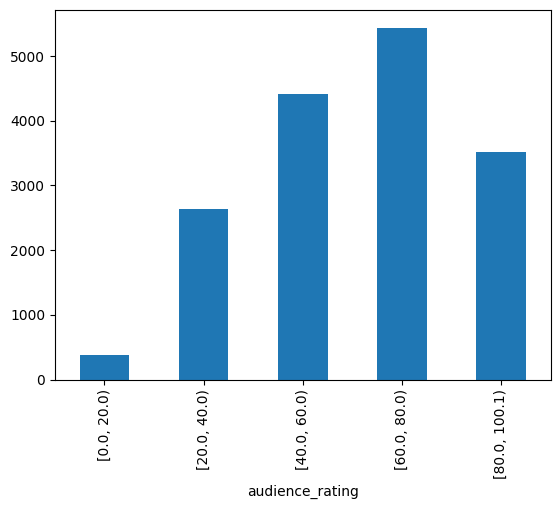

In [25]:
#tutorial de youtube que he seguido https://www.youtube.com/watch?v=r1ZVISvsaqU

#Miro los maxioss
maximos = {
    'runtime_in_minutes': df['runtime_in_minutes'].max(),
    'tomatometer_rating': df['tomatometer_rating'].max(),
    'audience_rating': df['audience_rating'].max(),
    'tomatometer_count': df['tomatometer_count'].max(),
    'audience_count': df['audience_count'].max()
}
display(maximos)
#Miro los minimos
minimos = {
    'runtime_in_minutes': df['runtime_in_minutes'].min(),
    'tomatometer_rating': df['tomatometer_rating'].min(),
    'audience_rating': df['audience_rating'].min(),
    'tomatometer_count': df['tomatometer_count'].min(),
    'audience_count': df['audience_count'].min()
}
display(minimos)

#de momento pongo que haya 5 intervalos
intervalos = 5

#calcula los intervalos de cada atributo
anchos_intervalos = {
    key: (maximos[key] - minimos[key]) / intervalos
    for key in maximos.keys()
}
anchos_intervalos

#Hago la tabla de pfrequencias de audience_rating
tabla_frecuencias = pd.cut(df['audience_rating'], 
                          bins=intervalos, 
                          right=False).value_counts().sort_index()
display(tabla_frecuencias.to_frame(name='Frecuencia'))

tabla_frecuencias.plot(kind='bar')



## 3.1 Estadisticas globales

## 3.2 Análisis por género

## 3.3 Análisis por estudio o director

## 3.4 Analisis temporal

## 3.5 Análisis de retraso a streaming (si aplica)

## 4. Uso de NumPy para análisis auxiliar

## 5. Preguntes

## 6. Conclusiones

In [ ]:
# Conteo de valores nulos por columna
print("Valores nulos por columna:")
print(df.isna().sum())

# Rellenar NaN en columnas numéricas clave con valores por defecto
df.fillna({'screen_time(min)': 0, 'notifications': 0}, inplace=True)

# Eliminar filas que no tengan app o tiempo de pantalla (esenciales para análisis)
df.dropna(subset=['critics_consensus'], inplace=True)

print('\nDespués de limpieza de NaN:')
print(df.isna().sum())

display(df.head())


## 5. Eliminación de columnas vacías

In [ ]:
# Eliminamos columnas que estén completamente vacías
print("Columnas actuales del DataFrame:")
print(df.columns.tolist())
df.dropna(axis=1, how='all', inplace=True)

print("Columnas actuales del DataFrame:")
print(df.columns.tolist())


Columnas actuales del DataFrame:
['movie_title', 'movie_info', 'critics_consensus', 'rating', 'genre', 'directors', 'writers', 'cast', 'in_theaters_date', 'on_streaming_date', 'runtime_in_minutes', 'studio_name', 'tomatometer_status', 'tomatometer_rating', 'tomatometer_count', 'audience_rating', 'audience_count', 'columna_vacia']
Columnas actuales del DataFrame:
['movie_title', 'movie_info', 'critics_consensus', 'rating', 'genre', 'directors', 'writers', 'cast', 'in_theaters_date', 'on_streaming_date', 'runtime_in_minutes', 'studio_name', 'tomatometer_status', 'tomatometer_rating', 'tomatometer_count', 'audience_rating', 'audience_count']


## 6. Limpieza y normalización de texto (`.str` en Pandas)

In [ ]:
# Normalizar nombres de apps:
# - quitar espacios en blanco
# - poner la primera letra en mayúscula de cada palabra
# - eliminar espacios internos (Instagram  -> Instagram, 'YouTube Music' -> 'Youtubemusic')
df['app_name'] = (
    df['app_name']
      .astype(str)
      .str.strip()
      .str.title()
      .str.replace(' ', '', regex=False)
)
 
display(df[['app_name']].head(10))
 
# Buscar todas las filas que contienen "Youtube"
youtube_rows = df[df['app_name'].str.contains('Youtube', case=False, na=False)]
print("Filas con Youtube:")
display(youtube_rows)

## 7. Métodos extra de cadena (`str.len`, `str.startswith`, etc.)

In [ ]:
# Longitud del nombre de la app
df['app_name_len'] = df['app_name'].str.len()

# Apps que empiezan por 'Y'
apps_y = df[df['app_name'].str.startswith('Y', na=False)]

print("Apps que empiezan por 'Y':")
display(apps_y[['app_name', 'app_name_len']].drop_duplicates())

display(df[['app_name', 'app_name_len']].head())


## 8. Detección de tipos mezclados en columnas

In [ ]:
print("Tipos actuales:")
print(df.dtypes)

print("\nTipo real de cada celda en las primeras filas:")
display(df.applymap(type).head())

# Convertir automáticamente al tipo más adecuado (opcional)
df = df.convert_dtypes()

print("\nTipos tras convert_dtypes():")
print(df.dtypes)


## 9. Guardar el dataset limpio

In [ ]:
df.to_csv('screentime_analysis_clean.csv', index=False)
print('Archivo screentime_analysis_clean.csv guardado correctamente.')

Archivo screentime_analysis_clean.csv guardado correctamente.


## 10. Mini análisis final por aplicación

In [ ]:
# ¿Qué apps tienen más tiempo medio de pantalla?
screen_time_media = (
    df.groupby('app_name')['screen_time(min)']
      .mean()
      .sort_values(ascending=False)
)

print("Tiempo medio de pantalla (min) por app:")
display(screen_time_media)

# ¿Qué apps generan más notificaciones?
notif_media = (
    df.groupby('app_name')['notifications']
      .mean()
      .sort_values(ascending=False)
)

print("Notificaciones medias por app:")
display(notif_media)
